[![Open in nbviewer](https://img.shields.io/badge/Open%20in-nbviewer-orange?logo=jupyter)](https://nbviewer.org/github/eacooper/NymeriaGazeTools/blob/main/examples/individual_gaze_analysis.ipynb)

> **Charts are interactive on nbviewer** — zoom, pan, and hover over data points. On GitHub, charts appear blank due to JavaScript restrictions.

In [ ]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"

In [17]:
from pathlib import Path
import nymeria_gaze_tools as ngt

DATA_ROOT = Path("../data/processed")

# SESSION = "20230614_s0_elizabeth_sandoval_act0_bzf7du"
# SESSION = "20230607_s0_james_johnson_act3_ifj2gc"
SESSION   = "20231128_s0_paul_nguyen_act0_3iqj71"
# SESSION = "20230607_s0_james_johnson_act1_7xwm28"

In [18]:
catalog = ngt.load_metadata(data_root=DATA_ROOT)
meta    = catalog[catalog["sequence_uid"] == SESSION].iloc[0].to_dict()
raw     = ngt.load_session(SESSION, data_root=DATA_ROOT)
print(f"Loaded: {len(raw)} rows")

Loaded: 11842 rows


In [19]:
df = ngt.preprocess(raw)
print(f"Preprocessed: {len(df)} rows")

Preprocessed: 11598 rows


In [20]:
sampling_rate_hz = ngt.compute_sampling_rate(raw)
fixations        = ngt.get_fixation_table(df, sample_rate_hz=sampling_rate_hz)
print(f"Fixations: {len(fixations)}")

Fixations: 1595


In [21]:
saccades = ngt.get_saccade_table(fixations.to_dict("records"), df=df)
print(f"Saccades: {len(saccades)}")

Saccades: 1594


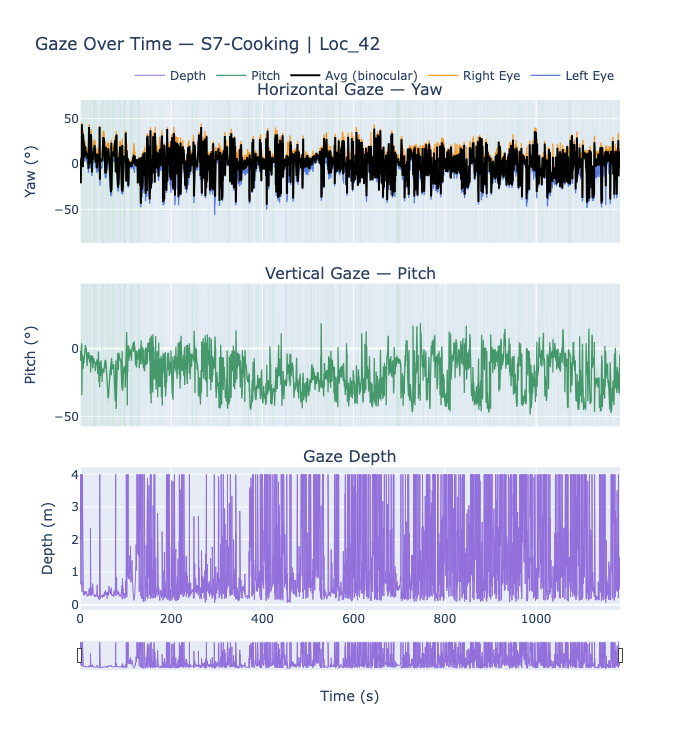

In [22]:
ngt.plot_gaze_timeseries(df, fixations=fixations, meta=meta).show()

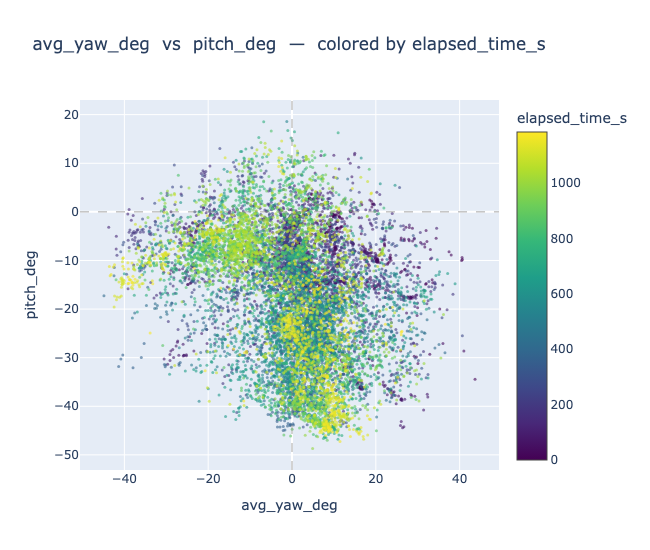

In [23]:
ngt.plot_gaze_scatter(df).show()

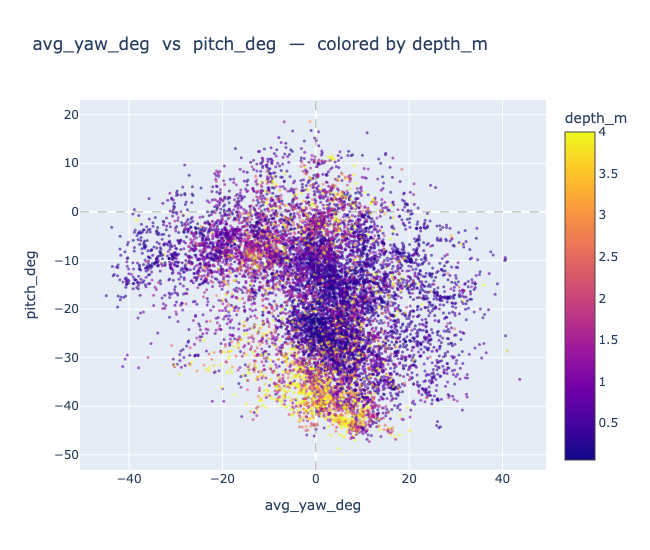

In [24]:
ngt.plot_gaze_scatter(df, color="depth_m", colormap="plasma").show()

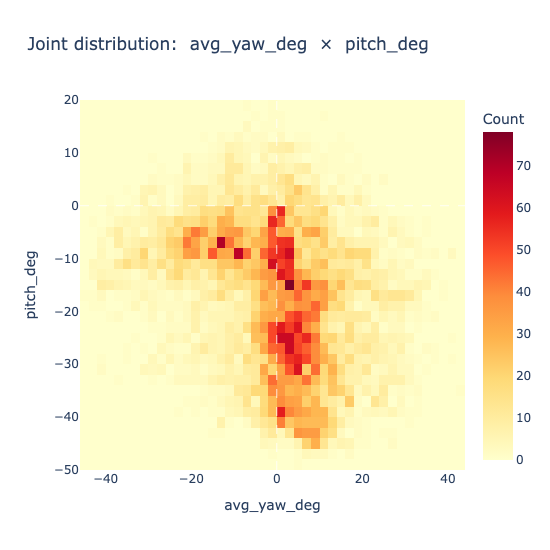

In [25]:
ngt.plot_gaze_heatmap(df).show()

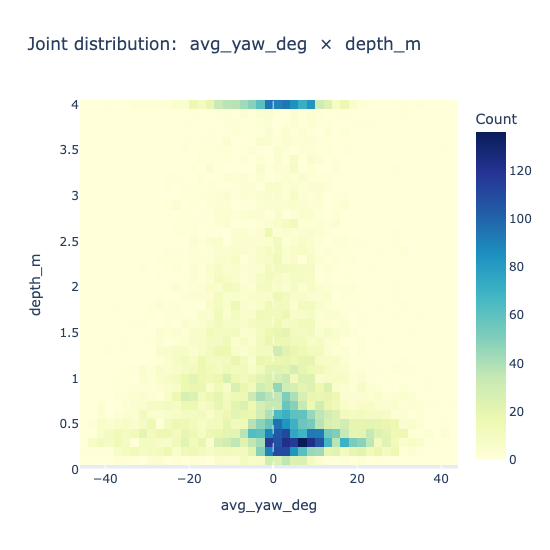

In [26]:
ngt.plot_gaze_heatmap(df, x="avg_yaw_deg", y="depth_m", colormap="YlGnBu").show()

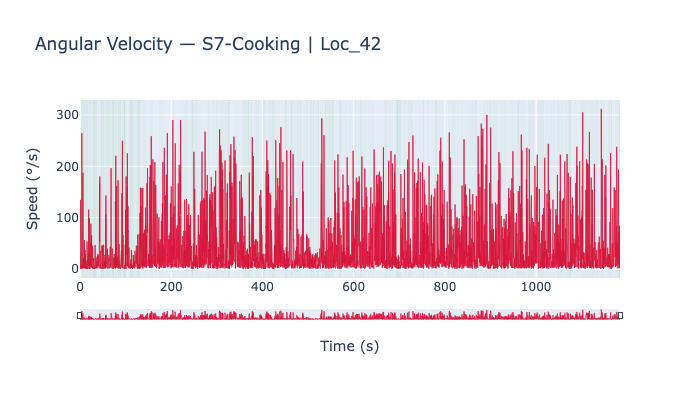

In [27]:
ngt.plot_velocity_trace(df, fixations=fixations, meta=meta).show()

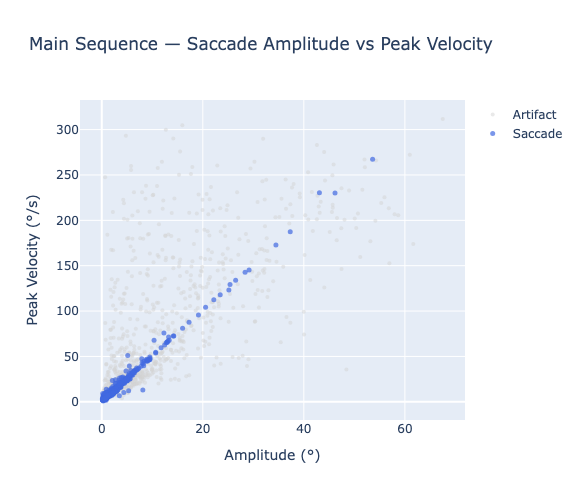

In [28]:
ngt.plot_main_sequence(saccades).show()

In [29]:
print(f"Fixations : {len(fixations)}")
print(f"Saccades  : {len(saccades)}")
summary = ngt.session_summary(df, fixations=fixations, saccades=saccades,
                              sampling_rate_hz=sampling_rate_hz, **meta)
print(summary.T)

Fixations : 1595
Saccades  : 1594
                                                         0
sequence_uid           20231128_s0_paul_nguyen_act0_3iqj71
date                                              20231128
session_id                                              s0
fake_name                                      paul_nguyen
act_id                                                act0
location                                            Loc_42
script                                          S7-Cooking
participant_gender                                    Male
participant_height_cm                                164.0
participant_weight_kg                                 58.0
participant_bmi                                       21.6
participant_age_group                                18-24
participant_ethnicity                      Southeast Asian
gaze_type                                     personalized
has_gaze_data                                         True
recording_duration_s  